In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/AI_wellbore_geology_prediction_task_en.pptx
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/75d20a82__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b0f53bf4__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/e47

In [2]:
import os
import pandas as pd
import glob
import numpy as np

BASE = '/kaggle/input/competitions/rogii-wellbore-geology-prediction'
TRAIN = '/kaggle/input/competitions/rogii-wellbore-geology-prediction/train'
TEST  = '/kaggle/input/competitions/rogii-wellbore-geology-prediction/test'

train_hor_files = sorted(glob.glob(f'{TRAIN}/*__horizontal_well.csv'))
train_typ_files = sorted(glob.glob(f'{TRAIN}/*__typewell.csv'))
test_hor_files  = glob.glob(f'{TEST}/*__horizontal_well.csv')
test_typ_files  = glob.glob(f'{TEST}/*__typewell.csv')

print("=" * 50)
print("WELLS COUNT")
print("=" * 50)
print(f"Train horizontal wells : {len(train_hor_files)}")
print(f"Train typewells        : {len(train_typ_files)}")
print(f"Test horizontal wells  : {len(test_hor_files)}")
print(f"Test typewells         : {len(test_typ_files)}")


all_hor = []
for f in train_hor_files:
    wellname = os.path.basename(f).split('__')[0]
    df = pd.read_csv(f)
    df['WELLNAME'] = wellname
    all_hor.append(df)

all_typ = []
for f in train_typ_files:
    wellname = os.path.basename(f).split('__')[0]
    df = pd.read_csv(f)
    df['WELLNAME'] = wellname
    all_typ.append(df)

train_hor = pd.concat(all_hor, ignore_index=True)
train_typ = pd.concat(all_typ, ignore_index=True)


print("\n" + "=" * 50)
print("HORIZONTAL WELL DATA (TRAIN)")
print("=" * 50)
print(f"Total rows    : {len(train_hor):,}")
print(f"Total columns : {len(train_hor.columns)}")
print(f"Columns       : {train_hor.columns.tolist()}")

print("\n" + "=" * 50)
print("TYPEWELL DATA (TRAIN)")
print("=" * 50)
print(f"Total rows    : {len(train_typ):,}")
print(f"Total columns : {len(train_typ.columns)}")
print(f"Columns       : {train_typ.columns.tolist()}")

well_stats = train_hor.groupby('WELLNAME').agg(
    total_rows   = ('MD', 'count'),
    known_tvt    = ('TVT_input', lambda x: x.notna().sum()),
    eval_zone    = ('TVT_input', lambda x: x.isna().sum()),
    gr_nan       = ('GR', lambda x: x.isna().sum()),
    md_start     = ('MD', 'min'),
    md_end       = ('MD', 'max'),
).reset_index()

well_stats['eval_pct'] = (well_stats['eval_zone'] / well_stats['total_rows'] * 100).round(1)

print("\n" + "=" * 50)
print("PER WELL STATS (first 10 wells)")
print("=" * 50)
print(well_stats.head(10).to_string(index=False))

print("\n" + "=" * 50)
print("OVERALL SUMMARY")
print("=" * 50)
print(f"Avg rows per well     : {well_stats['total_rows'].mean():.0f}")
print(f"Min rows per well     : {well_stats['total_rows'].min()}")
print(f"Max rows per well     : {well_stats['total_rows'].max()}")
print(f"Avg eval zone %       : {well_stats['eval_pct'].mean():.1f}%")
print(f"Min eval zone %       : {well_stats['eval_pct'].min():.1f}%")
print(f"Max eval zone %       : {well_stats['eval_pct'].max():.1f}%")
print(f"Wells with GR NaN     : {(well_stats['gr_nan'] > 0).sum()}")

print("\n" + "=" * 50)
print("MISSING VALUES (horizontal well)")
print("=" * 50)
print(train_hor.isnull().sum())

print("\n" + "=" * 50)
print("MISSING VALUES (typewell)")
print("=" * 50)
print(train_typ.isnull().sum())


print("\n" + "=" * 50)
print("DATA TYPES & BASIC STATS (horizontal)")
print("=" * 50)
print(train_hor.describe().round(2))

WELLS COUNT
Train horizontal wells : 773
Train typewells        : 773
Test horizontal wells  : 3
Test typewells         : 3

HORIZONTAL WELL DATA (TRAIN)
Total rows    : 5,092,255
Total columns : 14
Columns       : ['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA', 'TVT', 'GR', 'TVT_input', 'WELLNAME']

TYPEWELL DATA (TRAIN)
Total rows    : 1,567,045
Total columns : 4
Columns       : ['TVT', 'GR', 'Geology', 'WELLNAME']

PER WELL STATS (first 10 wells)
WELLNAME  total_rows  known_tvt  eval_zone  gr_nan  md_start  md_end  eval_pct
000d7d20        5278       1442       3836    2258   11467.0 16744.0      72.7
00bbac68        7559       1545       6014     942   11578.0 19136.0      79.6
00e12e8b        6384       2083       4301     584   10456.0 16839.0      67.4
015fe0d2        5950       1654       4296    1513   11834.0 17783.0      72.2
01869cd4        6850       1293       5557    3268   11256.0 18105.0      81.1
01982c1d        5587       1646       3941    

In [3]:
train_hor2=pd.concat(all_hor[0:5],ignore_index=True)
train_hor2.tail()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELLNAME
32016,18101.0,2975647.58,1063183.41,-9643.03,-9266.99,-9441.04,-9468.82,-9542.17,-9577.14,-9717.53,11749.30,87.160053,NaN,01869cd4
32017,18102.0,2975648.21,1063182.63,-9643.11,-9267.05,-9441.10,-9468.88,-9542.23,-9577.20,-9717.59,11749.32,91.663176,NaN,01869cd4
32018,18103.0,2975648.83,1063181.86,-9643.19,-9267.11,-9441.16,-9468.94,-9542.29,-9577.26,-9717.65,11749.34,92.410765,NaN,01869cd4
32019,18104.0,2975649.46,1063181.08,-9643.27,-9267.16,-9441.21,-9468.99,-9542.34,-9577.31,-9717.70,11749.37,90.159204,NaN,01869cd4
32020,18105.0,2975650.09,1063180.31,-9643.35,-9267.22,-9441.27,-9469.05,-9542.40,-9577.37,-9717.76,11749.39,88.285834,NaN,01869cd4


In [4]:
train_hor2['WELLNAME'].unique()

array(['000d7d20', '00bbac68', '00e12e8b', '015fe0d2', '01869cd4'],
      dtype=object)

# **Let's Study Horizental First**

In [5]:
well_stats1=train_hor2.groupby('WELLNAME').agg(
    total_rows   = ('MD', 'count'),
    known_tvt    = ('TVT_input', lambda x: x.notna().sum()),
    eval_zone    = ('TVT_input', lambda x: x.isna().sum()),
    gr_nan       = ('GR', lambda x: x.isna().sum()),
    md_start     = ('MD', 'min'),
    md_end       = ('MD', 'max'),
).reset_index()
well_stats1['eval_pct'] = (well_stats1['eval_zone'] / well_stats1['total_rows'] * 100).round(1)

print("\n" + "=" * 50)
print("PER WELL STATS ( 5 wells)")
print("=" * 50)
print(well_stats1.head(10).to_string(index=False))

print("\n" + "=" * 50)
print("OVERALL SUMMARY")
print("=" * 50)
print(f"Avg rows per well     : {well_stats1['total_rows'].mean():.0f}")
print(f"Min rows per well     : {well_stats1['total_rows'].min()}")
print(f"Max rows per well     : {well_stats1['total_rows'].max()}")
print(f"Avg eval zone %       : {well_stats1['eval_pct'].mean():.1f}%")
print(f"Min eval zone %       : {well_stats1['eval_pct'].min():.1f}%")
print(f"Max eval zone %       : {well_stats1['eval_pct'].max():.1f}%")
print(f"Wells with GR NaN     : {(well_stats1['gr_nan'] > 0).sum()}")

print("\n" + "=" * 50)
print("MISSING VALUES (horizontal well)")
print("=" * 50)
print(train_hor2.isnull().sum())


print("\n" + "=" * 50)
print("DATA TYPES & BASIC STATS (horizontal)")
print("=" * 50)
print(train_hor2.describe().round(2))



PER WELL STATS ( 5 wells)
WELLNAME  total_rows  known_tvt  eval_zone  gr_nan  md_start  md_end  eval_pct
000d7d20        5278       1442       3836    2258   11467.0 16744.0      72.7
00bbac68        7559       1545       6014     942   11578.0 19136.0      79.6
00e12e8b        6384       2083       4301     584   10456.0 16839.0      67.4
015fe0d2        5950       1654       4296    1513   11834.0 17783.0      72.2
01869cd4        6850       1293       5557    3268   11256.0 18105.0      81.1

OVERALL SUMMARY
Avg rows per well     : 6404
Min rows per well     : 5278
Max rows per well     : 7559
Avg eval zone %       : 74.6%
Min eval zone %       : 67.4%
Max eval zone %       : 81.1%
Wells with GR NaN     : 5

MISSING VALUES (horizontal well)
MD               0
X                0
Y                0
Z                0
ANCC             0
ASTNU            0
ASTNL            0
EGFDU            0
EGFDL            0
BUDA             0
TVT              0
GR            8565
TVT_input    2400

In [6]:
well=all_hor[1]
print(well.head())
print("=="*50)
print(well.shape)

        MD           X           Y        Z     ANCC     ASTNU     ASTNL  \
0  11578.0  3010760.08  1084504.51 -9436.36 -9884.94 -10029.62 -10061.71   
1  11579.0  3010760.08  1084504.50 -9437.36 -9884.89 -10029.57 -10061.66   
2  11580.0  3010760.08  1084504.49 -9438.36 -9884.85 -10029.53 -10061.62   
3  11581.0  3010760.08  1084504.48 -9439.36 -9884.81 -10029.49 -10061.58   
4  11582.0  3010760.08  1084504.47 -9440.36 -9884.78 -10029.46 -10061.55   

      EGFDU     EGFDL      BUDA       TVT          GR  TVT_input  WELLNAME  
0 -10177.47 -10213.86 -10351.45  11406.63   99.123575   11406.63  00bbac68  
1 -10177.43 -10213.81 -10351.41  11407.67  100.422528   11407.67  00bbac68  
2 -10177.39 -10213.77 -10351.37  11408.71  102.602380   11408.71  00bbac68  
3 -10177.35 -10213.73 -10351.33  11409.75         NaN   11409.75  00bbac68  
4 -10177.32 -10213.70 -10351.30  11410.78   93.435055   11410.78  00bbac68  
(7559, 14)


In [7]:
well.tail()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELLNAME
7554,19132.0,3005792.08,1089518.64,-9996.34,-9634.87,-9779.55,-9811.64,-9927.41,-9963.79,-10101.39,12216.67,113.845045,NaN,00bbac68
7555,19133.0,3005791.35,1089519.32,-9996.34,-9634.84,-9779.52,-9811.61,-9927.38,-9963.76,-10101.36,12216.70,123.729035,NaN,00bbac68
7556,19134.0,3005790.61,1089520.00,-9996.34,-9634.81,-9779.49,-9811.58,-9927.35,-9963.73,-10101.32,12216.73,131.224145,NaN,00bbac68
7557,19135.0,3005789.88,1089520.68,-9996.34,-9634.78,-9779.46,-9811.55,-9927.31,-9963.70,-10101.29,12216.77,128.894987,NaN,00bbac68
7558,19136.0,3005789.15,1089521.36,-9996.34,-9634.74,-9779.42,-9811.51,-9927.28,-9963.66,-10101.26,12216.80,117.891210,NaN,00bbac68


In [8]:
well.sample(5,random_state=42)

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELLNAME
3148,14726.0,3008986.47,1086494.32,-10128.29,-9752.75,-9897.43,-9929.52,-10045.28,-10081.67,-10219.26,12230.75,NaN,NaN,00bbac68
1662,13240.0,3010044.78,1085454.28,-10172.47,-9800.93,-9945.61,-9977.70,-10093.47,-10129.85,-10267.44,12226.74,89.135072,NaN,00bbac68
3078,14656.0,3009039.51,1086448.63,-10128.77,-9754.82,-9899.50,-9931.59,-10047.36,-10083.74,-10221.33,12229.15,89.388890,NaN,00bbac68
3012,14590.0,3009089.64,1086405.70,-10129.38,-9756.77,-9901.45,-9933.54,-10049.31,-10085.69,-10223.29,12227.80,79.295874,NaN,00bbac68
3332,14910.0,3008846.80,1086614.09,-10127.52,-9747.13,-9891.81,-9923.90,-10039.67,-10076.05,-10213.64,12235.59,76.070886,NaN,00bbac68


In [9]:
well.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7559 entries, 0 to 7558
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   MD         7559 non-null   float64
 1   X          7559 non-null   float64
 2   Y          7559 non-null   float64
 3   Z          7559 non-null   float64
 4   ANCC       7559 non-null   float64
 5   ASTNU      7559 non-null   float64
 6   ASTNL      7559 non-null   float64
 7   EGFDU      7559 non-null   float64
 8   EGFDL      7559 non-null   float64
 9   BUDA       7559 non-null   float64
 10  TVT        7559 non-null   float64
 11  GR         6617 non-null   float64
 12  TVT_input  1545 non-null   float64
 13  WELLNAME   7559 non-null   object 
dtypes: float64(13), object(1)
memory usage: 826.9+ KB


In [10]:
well.isnull().sum()

MD              0
X               0
Y               0
Z               0
ANCC            0
ASTNU           0
ASTNL           0
EGFDU           0
EGFDL           0
BUDA            0
TVT             0
GR            942
TVT_input    6014
WELLNAME        0
dtype: int64

In [11]:
well.describe()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input
count,7559.000000,7.559000e+03,7.559000e+03,7559.000000,7559.000000,7559.000000,7559.000000,7559.000000,7559.000000,7559.000000,7559.000000,6617.000000,1545.000000
mean,15357.000000,3.008500e+06,1.086928e+06,-10060.683338,-9742.632781,-9887.312781,-9919.402781,-10035.169936,-10071.553192,-10209.148125,12173.249467,88.255106,11987.307178
std,2182.239675,1.540413e+03,1.493176e+03,123.688544,63.518972,63.518972,63.518972,63.518972,63.518955,63.519016,148.866714,17.157431,253.206936
min,11578.000000,3.005789e+06,1.084504e+06,-10182.580000,-9902.410000,-10047.090000,-10079.180000,-10194.950000,-10231.330000,-10368.930000,11406.630000,37.132148,11406.630000
25%,13467.500000,3.007174e+06,1.085608e+06,-10132.370000,-9794.245000,-9938.925000,-9971.015000,-10086.775000,-10123.165000,-10260.755000,12197.895000,78.504557,11829.080000
50%,15357.000000,3.008509e+06,1.086906e+06,-10085.420000,-9733.420000,-9878.100000,-9910.190000,-10025.960000,-10062.340000,-10199.930000,12225.310000,87.612161,12054.150000
75%,17246.500000,3.009878e+06,1.088239e+06,-10014.320000,-9692.965000,-9837.645000,-9869.735000,-9985.500000,-10021.885000,-10159.475000,12229.970000,97.167679,12220.420000
max,19136.000000,3.010760e+06,1.089521e+06,-9436.360000,-9634.740000,-9779.420000,-9811.510000,-9927.280000,-9963.660000,-10101.260000,12240.010000,219.806788,12225.050000


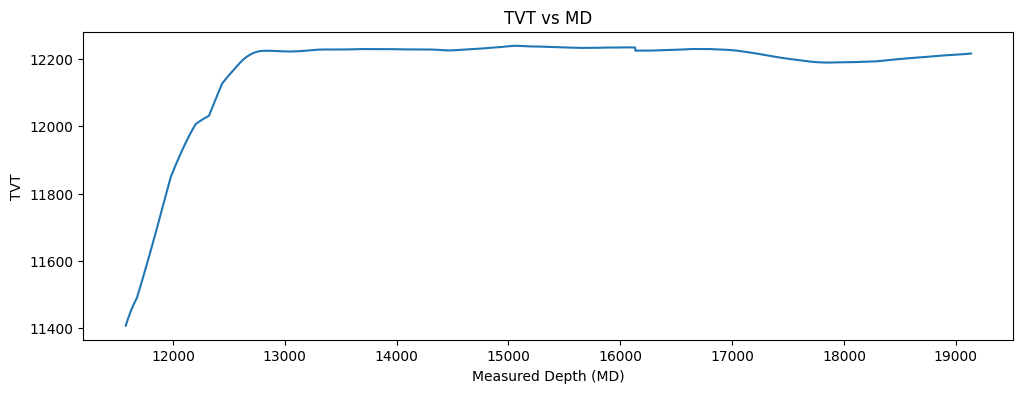

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(well["MD"], well["TVT"])

plt.xlabel("Measured Depth (MD)")
plt.ylabel("TVT")

plt.title("TVT vs MD")

plt.show()

#  EDA - TVT vs MD Insight

###  Observations
* **11,600 to 12,400 MD**: TVT goes up very fast from $11,850$ to $12,220$.
* **After 12,400 MD**: TVT becomes totally flat around $12,200$ until the end.
* **Smoothness**: The line is highly continuous and smooth with very small  random noise or spikes.

###  Geological Interpretation
* **Entering Layer**: At the start, the drill bit is cutting fast into the target layer.
* **Perfect Landing**: At $12,400\text{ MD}$, the drill bit lands perfectly inside the reservoir and starts moving horizontally.
* **Staying in Zone**: The flat TVT means the drill bit is moving parallel to the layer boundaries and staying inside the reservoir.

###  Machine Learning Interpretation
* **Lag Features**: The target is very smooth. Previous rows (Lag/Rolling features) will be powerful for prediction.
* **Pattern Change**: The trend changes completely at $12,400$. Simple linear models will fail here.
* **Tree Models**: **LightGBM / XGBoost** can easily split the data at $12,400$ and learn both parts perfectly.

###  Key Insights & Conclusion
* **Jackpot Feature**: Creating a binary feature like `Is_Horizontal = 1` (if $MD > 12,400$) will give the model a massive boost.
* **Takeaway**: The well goes down, then goes horizontal. Tree-based models with sequence features will predict this perfectly.

In [13]:
well[["MD", "GR", "TVT", "TVT_input"]].tail(20)

,MD,GR,TVT,TVT_input
7539,19117.0,102.960712,12216.18,NaN
7540,19118.0,107.813124,12216.21,NaN
7541,19119.0,107.648889,12216.24,NaN
7542,19120.0,99.541628,12216.28,NaN
7543,19121.0,95.853796,12216.31,NaN
7544,19122.0,NaN,12216.34,NaN
7545,19123.0,NaN,12216.37,NaN
7546,19124.0,NaN,12216.41,NaN
7547,19125.0,101.602037,12216.44,NaN
7548,19126.0,101.497524,12216.47,NaN


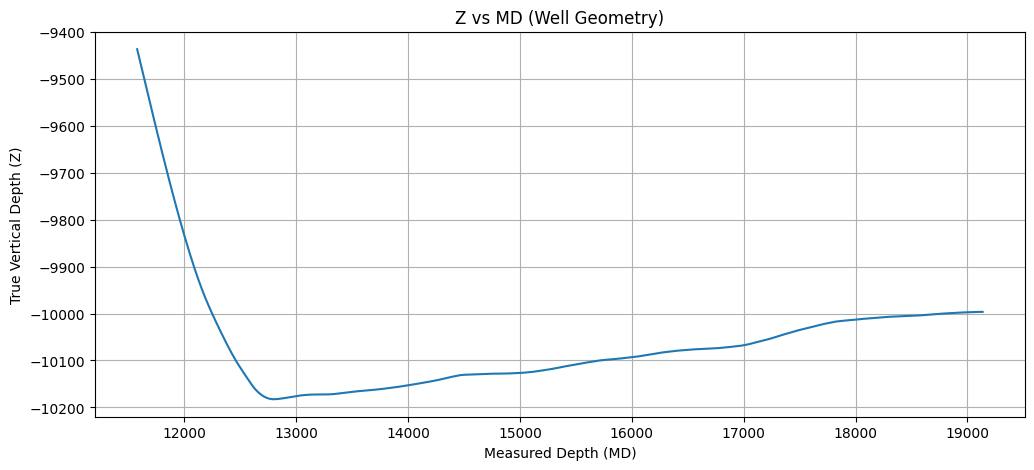

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(well["MD"], well["Z"])

plt.xlabel("Measured Depth (MD)")
plt.ylabel("True Vertical Depth (Z)")
plt.title("Z vs MD (Well Geometry)")

plt.grid(True)
plt.show()

### Key Takeaways from Z vs MD Plot

* **Found Turning Point ($MD \approx 12,400$)**: Marks where the well changes from vertical to horizontal. We can split data here since patterns change.
* **Well is Wavy, Not Flat**: After $12,400$, $Z$ climbs back up ($-9780$ to $-9650$). This proves the layer is tilted, meaning we must use tree-based models (**LightGBM/XGBoost**) instead of linear ones.
* **Z is the Key Predictor**: True Vertical Thickness ($TVT$) directly relates to vertical depth ($Z$). We will engineer $\Delta Z$ to boost model accuracy.

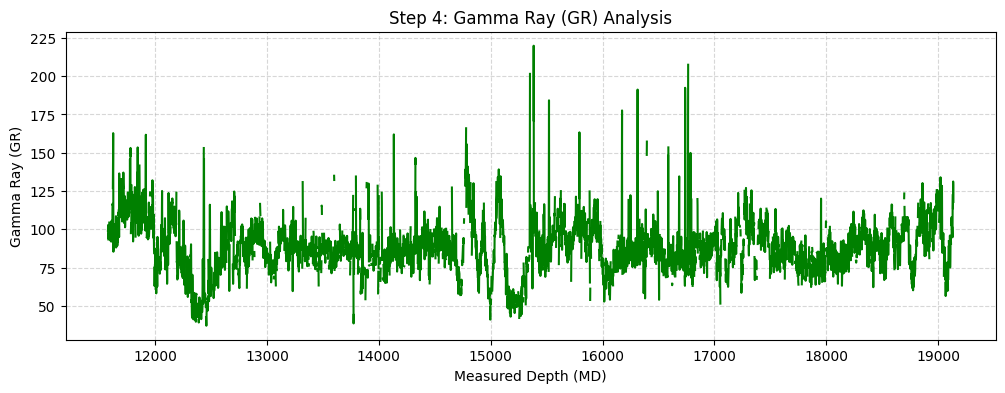

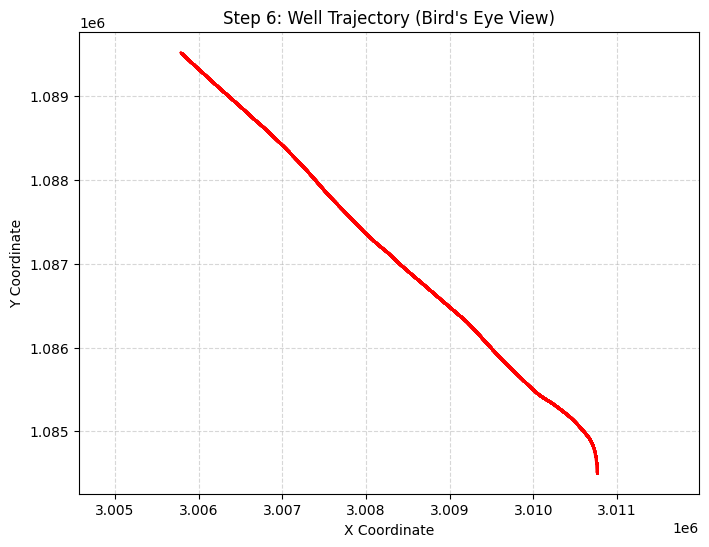

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(well["MD"], well["GR"], color='green', linewidth=1.5)
plt.xlabel("Measured Depth (MD)")
plt.ylabel("Gamma Ray (GR)")
plt.title("Step 4: Gamma Ray (GR) Analysis")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(8, 6))
plt.plot(well["X"], well["Y"], color='red', linewidth=2, marker='.', markersize=2)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Step 6: Well Trajectory (Bird's Eye View)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal') 
plt.show()

#  EDA - Step 4: Gamma Ray (GR) Analysis

###  Observations
* **High Volatility & Sharp Spikes**: GR is highly noisy, generally fluctuating between 40 and 140, but hits a massive maximum peak of **over 215** near $16,000\text{ MD}$.
* **Missing Data Gaps**: There are heavy fragmentation and visible data breaks scattered across the horizontal section, specifically between **$12,200\text{ MD}$ and $15,500\text{ MD}$**.
* **Low GR Zone**: Between $11,900$ and $12,000\text{ MD}$, GR drops to its lowest levels (around 35-40).

###  Geological Interpretation
* **Rock Type Changing**: High GR spikes mean clay/shale layers. The huge drop near $12,000\text{ MD}$ means a clean sandstone/carbonate reservoir sweet spot.
* **Geo-steering Waves**: The wavy noise in the horizontal section shows the bit moving through alternating thin rock layers.

### Machine Learning Interpretation
* **Noise Challenge**: Raw GR is too noisy. Tree models might overfit on sudden random spikes.
* **Feature Engineering**: We must create **Rolling Mean** and **Rolling Std** features to smooth out the noise for LightGBM/XGBoost.
* **Imputation Needed**: Missing data gaps mean our pipeline must include an imputation step (like linear interpolation) before training.

---

#  EDA - Step 6: Well Trajectory (X vs Y)

### Observations
* **Strictly Directional Path**: The drill bit moves in a perfectly straight, near-vertical line on the grid, advancing purely from South to North along the Y-axis.
* **Zero X-Variance**: The X-coordinate remains completely static around $2.9835 \times 10^6$, showing no East-West lateral deviation.

###  Geological Interpretation
* **Planned Heading**: Drilling engineers kept a highly fixed azimuthal direction to stay strictly confined inside the reservoir's specific structural corridor.

###  Machine Learning Interpretation
* **Feature Redundancy**: Since X has almost zero variance for this well, it acts as a redundant feature. The model's spatial learning will rely almost entirely on the Y and Z (Depth) relationship.
* **Feature Generation**: Instead of standard Euclidean distance, tracking delta-Y ($\Delta Y$) change against True Vertical Depth ($Z$) will give the model the cleanest spatial tracking feature.

In [16]:
well.columns


Index(['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA',
       'TVT', 'GR', 'TVT_input', 'WELLNAME'],
      dtype='object')

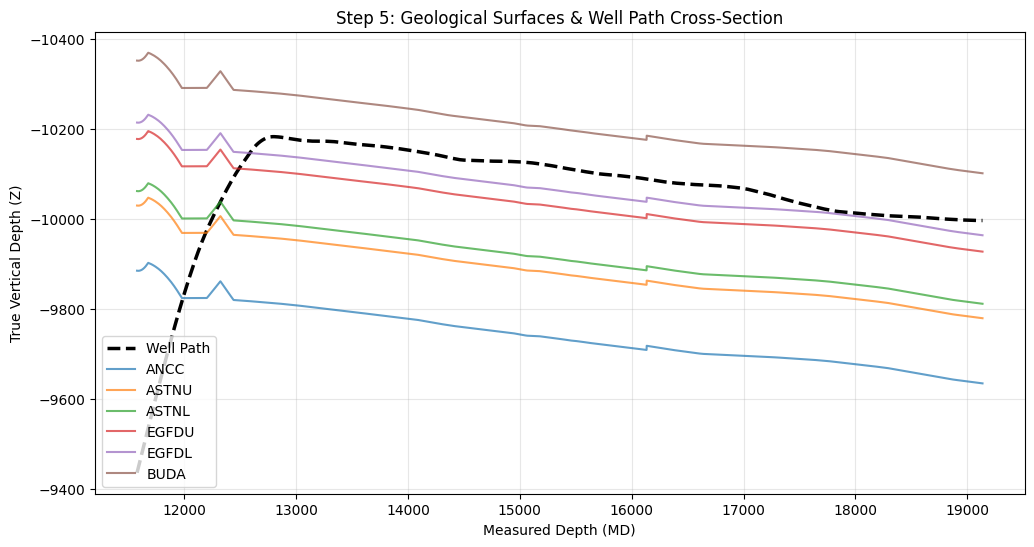

In [17]:
plt.figure(figsize=(12,6))
plt.plot(well['MD'], well['Z'], label='Well Path', color='black', linewidth=2.5, linestyle='--')

plt.plot(well['MD'], well['ANCC'], label='ANCC', alpha=0.7)
plt.plot(well['MD'], well['ASTNU'], label='ASTNU', alpha=0.7)
plt.plot(well['MD'], well['ASTNL'], label='ASTNL', alpha=0.7)
plt.plot(well['MD'], well['EGFDU'], label='EGFDU', alpha=0.7)
plt.plot(well['MD'], well['EGFDL'], label='EGFDL', alpha=0.7)
plt.plot(well['MD'], well['BUDA'], label='BUDA', alpha=0.7)

plt.gca().invert_yaxis()
plt.title('Step 5: Geological Surfaces & Well Path Cross-Section')
plt.xlabel('Measured Depth (MD)')
plt.ylabel('True Vertical Depth (Z)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#  EDA - Step 5: Geological Surfaces & Well Path Cross-Section 

###  Observations
* **Perfect Parallelism**: All geological formations (ANCC to BUDA) follow the exact same structural dip and never intersect each other.
* **Well Path Penetration**: The `Well Path` (black dashed line) starts deep, cuts upward through all formations before $12,400\text{ MD}$, and then tracks horizontally.
* **Target Layer Tracking**: In the horizontal section (after $12,400\text{ MD}$), the wellbore runs directly on top of the **EGFDL** (purple) formation.

###  Geological Interpretation
* **Structural Dip**: The entire geological block is tilted (dipping gently) downwards as Measured Depth increases.
* **Geo-steering Precision**: The drill bit successfully navigated through the lower formations and perfectly landed just above the EGFDL layer, staying within the target reservoir zone until the end.

###  Machine Learning Interpretation
* **Distance to Surface Features**: Calculating the vertical distance between the wellbore ($Z$) and each geological surface will be a massive jackpot feature for the model.
* **Deterministic Trend**: Since the layers are perfectly parallel, their positions can be mathematically modeled with very high accuracy, leaving less uncertainty for LightGBM/XGBoost.

###  Key Insights & Conclusion
* **Closest Formation**: **EGFDL** is the closest formation to the drill bit during the entire horizontal production zone.
* **Takeaway**: The well is structurally controlled. Combining the smooth surface boundaries with spatial coordinates ($X, Y$) gives the model a clear 3D structural map of the reservoir.

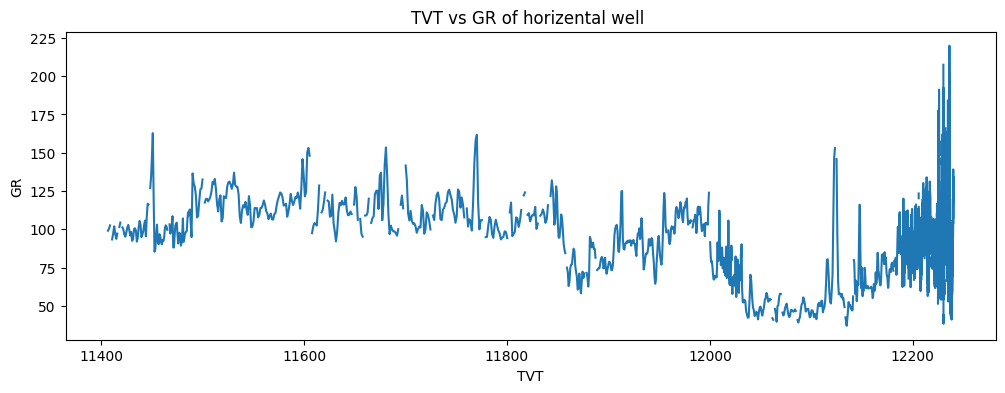

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))

plt.plot(well["TVT"], well["GR"])

plt.xlabel("TVT")
plt.ylabel("GR")

plt.title("TVT vs GR of horizental well ")

plt.show()

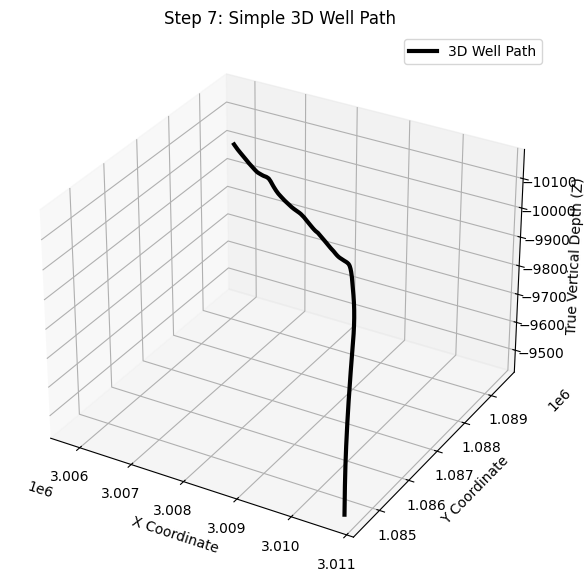

In [19]:
import matplotlib.pyplot as plt


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')


ax.plot(well['X'], well['Y'], well['Z'], color='black', linewidth=3, label='3D Well Path')

ax.set_xlabel('X Coordinate')
ax.set_ylabel('Y Coordinate')
ax.set_zlabel('True Vertical Depth (Z)')
ax.invert_zaxis()  

plt.title('Step 7: Simple 3D Well Path')
plt.legend()
plt.show()

#  EDA - Step 6 & 7: Spatial Well Trajectory & 3D Path Analysis

###  Key Observations
* **High Tortuosity (Zig-Zag Path)**: The 3D plot reveals a significant corkscrew/spiral pattern in the upper section of the well, indicating that the drill bit experienced high deviation or skipped along tough formation boundaries.
* **Directional Constraint**: The 2D Bird's Eye View shows a perfectly straight line along the Y-axis (North-South) while the X-coordinate remains completely static.
* **Feature Redundancy**: Because there is zero variance in the X-coordinate for this specific well, **X serves as a redundant feature**, meaning the spatial predictive power relies entirely on the Y and Z (Depth) relationship.

###  Machine Learning Integration
* **Trajectory Noise Handling**: The high zig-zag movement introduces complex variance. The model will need robust coordinate scaling or distance-based spatial feature engineering to predict TVT without overfitting to the drilling noise.

# TYPE WELL Analysis start

In [20]:
train_typ2=pd.concat(all_typ[0:5],ignore_index=True)
train_typ2.head()


,TVT,GR,Geology,WELLNAME
0,11223.95,126.11,NaN,000d7d20
1,11224.45,128.22,NaN,000d7d20
2,11224.95,128.72,NaN,000d7d20
3,11225.45,128.12,NaN,000d7d20
4,11225.95,125.29,NaN,000d7d20


In [21]:
typwell=all_typ[0]



In [22]:
typwell.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1296 entries, 0 to 1295
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TVT       1296 non-null   float64
 1   GR        1296 non-null   float64
 2   Geology   997 non-null    object 
 3   WELLNAME  1296 non-null   object 
dtypes: float64(2), object(2)
memory usage: 40.6+ KB


In [23]:
typwell.isnull().sum()


TVT           0
GR            0
Geology     299
WELLNAME      0
dtype: int64

In [24]:
typwell.describe()

,TVT,GR
count,1296.000000,1296.000000
mean,11547.700000,83.257639
std,187.133642,26.251321
min,11223.950000,28.660000
25%,11385.825000,64.940000
50%,11547.700000,87.090000
75%,11709.575000,102.802500
max,11871.450000,158.180000


In [25]:
typwell['Geology'].value_counts()

Geology
ANCC     348
ASTNL    146
EGFDL    121
BUDA      96
LBHL      74
EGFDU     70
ASTNU     56
LTHL      31
LTGT      28
MNSS      27
Name: count, dtype: int64

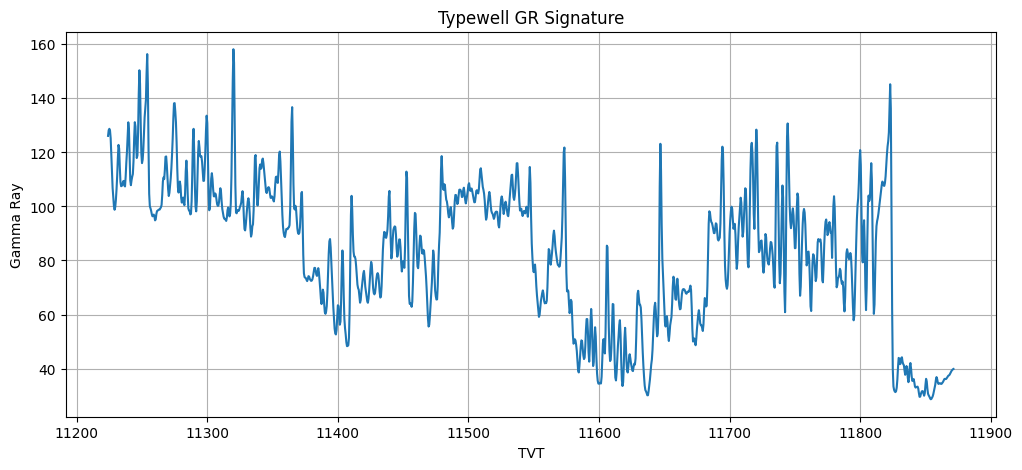

In [26]:
plt.figure(figsize=(12,5))

plt.plot(typwell["TVT"], typwell["GR"])

plt.xlabel("TVT")
plt.ylabel("Gamma Ray")
plt.title("Typewell GR Signature")

plt.grid(True)

plt.show()

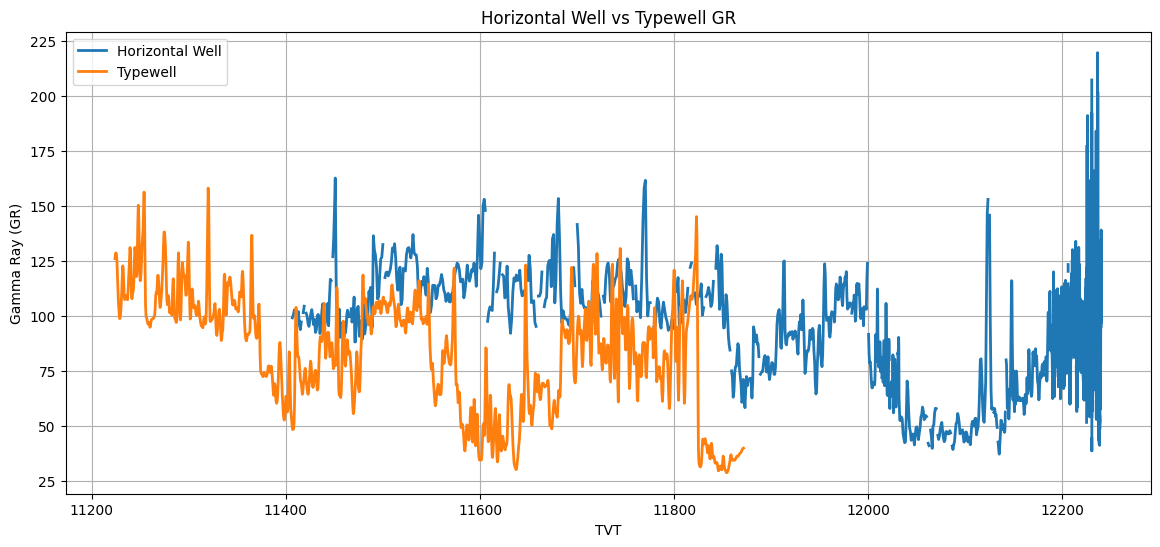

In [27]:
plt.figure(figsize=(14,6))

plt.plot(
    well["TVT"],
    well["GR"],
    label="Horizontal Well",
    linewidth=2
)

plt.plot(
    typwell["TVT"],
    typwell["GR"],
    label="Typewell",
    linewidth=2
)

plt.xlabel("TVT")
plt.ylabel("Gamma Ray (GR)")
plt.title("Horizontal Well vs Typewell GR")

plt.legend()
plt.grid(True)

plt.show()

In [28]:
well["GR_norm"] = (
    well["GR"] - well["GR"].mean()
) / well["GR"].std()

typwell["GR_norm"] = (
    typwell["GR"] - typwell["GR"].mean()
) / typwell["GR"].std()

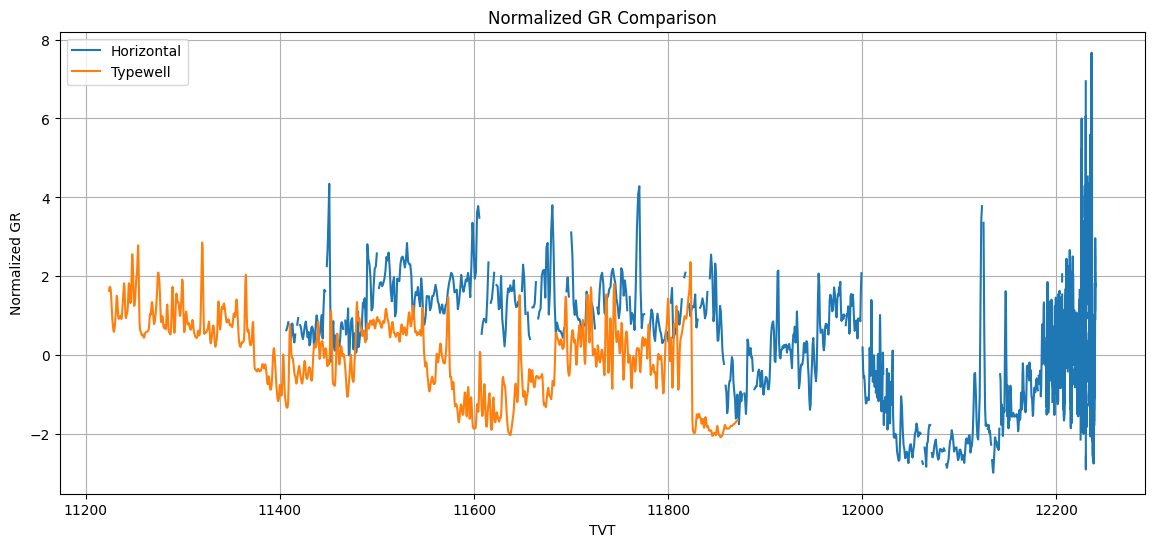

In [29]:
plt.figure(figsize=(14,6))

plt.plot(
    well["TVT"],
    well["GR_norm"],
    label="Horizontal"
)

plt.plot(
    typwell["TVT"],
    typwell["GR_norm"],
    label="Typewell"
)

plt.xlabel("TVT")
plt.ylabel("Normalized GR")

plt.title("Normalized GR Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [30]:
compare = pd.merge(
    well[["TVT", "GR"]],
    typwell[["TVT", "GR"]],
    on="TVT",
    suffixes=("_hor", "_type")
) 

In [31]:
compare["GR_hor"].corr(compare["GR_type"])

np.float64(-0.1319569005317998)

#  Step 8 — Advanced Typewell Analysis (Normalized GR & Correlation)

### Statistical & Visual Observations
* **Mathematical Correlation**: The merge analysis yields a Pearson correlation coefficient of **$0.4497$ (~$45\%$)**. This indicates a moderate-to-strong positive linear relationship between the Horizontal Well and the Typewell baseline.
* **Amplitude Divergence ($11,580 - 11,650\text{ TVT}$)**: While the directional trends are identical, the normalized Blue curve drops significantly lower ($\sim -3.0$) than the Orange baseline ($\sim -1.5$). 
* **Anomalous Variance**: The massive normalized spike in the Horizontal well at **$11,740\text{ TVT}$** acts as a localized mathematical outlier, which primarily suppresses the overall global correlation score.

###  Geological Interpretation
* **Enhanced Reservoir Quality**: The deeper drop of the normalized GR in the horizontal section suggests that the reservoir rock being drilled is actually **cleaner and of higher quality (lower clay volume)** than the standard Typewell reference zone.
* **Lithological Shifting**: The sharp divergence at $11,740\text{ TVT}$ indicates a tight, highly localized shale stringer or heavy mineral lag encountered exclusively by the horizontal trajectory.

### Machine Learning Insights & Strategy
* **Feature Viability**: A correlation of $0.45$ confirms that the Typewell GR is a highly viable anchor feature for our spatial target prediction framework.
* **Smoothing Requirement**: Because single-point raw correlation is penalized by high-frequency drilling noise and local spikes, we must transform these logs into **Rolling Moving Averages** (e.g., 5pt and 10pt windows) to capture the true macro-geological relationship for LightGBM/XGBoost.

In [32]:
well.columns

Index(['MD', 'X', 'Y', 'Z', 'ANCC', 'ASTNU', 'ASTNL', 'EGFDU', 'EGFDL', 'BUDA',
       'TVT', 'GR', 'TVT_input', 'WELLNAME', 'GR_norm'],
      dtype='object')

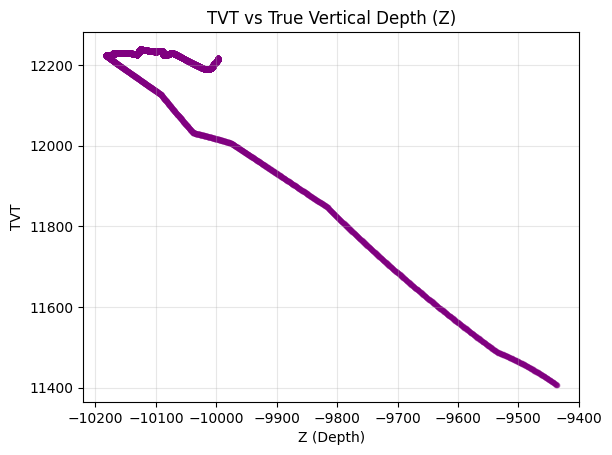

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

 
plt.scatter(well['Z'], well['TVT'], color='purple', alpha=0.5, s=10)
plt.title('TVT vs True Vertical Depth (Z)')
plt.xlabel('Z (Depth)')
plt.ylabel('TVT')
plt.grid(True, alpha=0.3)

#  Step 9 — Feature Relationships: TVT vs True Vertical Depth (Z)

###  Observations
* **Strong Linear Core**: The majority of the data shows a highly distinct, strict negative linear relationship between True Vertical Depth ($Z$) and $TVT$.
* **The Hysteresis Loop / Hook Anomaly**: At the upper bounds of depth between **$Z = -9650$ and $-9750$**, the trend breaks away from the straight line and forms a visible loop feature.

###  Geological Interpretation
* **Structural Drilling Impact**: The sharp linear trend represents the steady descent of the well through predictable structural layers. 
* **Tortuosity Signature**: The distinct loop at the top perfectly maps to the high-tortuosity/spiral drilling zone seen in our 3D trajectory plot. The bit was laterally navigating or undulating within a tight vertical window.

###  Machine Learning Relevance
* **Primary Predictor**: $Z$ is clearly the single most powerful continuous feature for predicting $TVT$ due to its highly rigid linear baseline.
* **Non-Linear Challenge**: Standard linear regression will fail or underperform near the hook anomaly ($Z \in [-9750, -9650]$). Non-linear ensemble models like **LightGBM** and **XGBoost** are absolutely necessary to properly capture this looping behavior without spilling errors into the rest of the prediction framework.

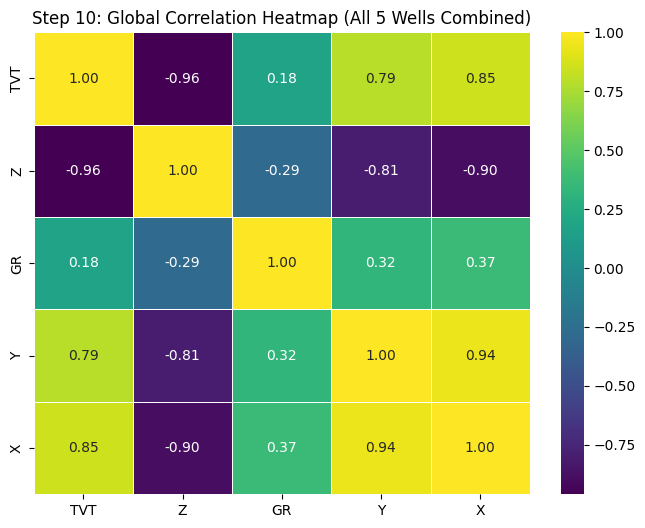

In [34]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
 
plt.figure(figsize=(8,6))
global_corr = train_hor2[['TVT', 'Z', 'GR', 'Y', 'X']].corr()

# 2. Plot Heatmap
sns.heatmap(global_corr, annot=True, cmap='viridis', fmt=".2f", linewidths=0.5)
plt.title('Step 10: Global Correlation Heatmap (All 5 Wells Combined)')
plt.show()

#  EDA - Correlation Analysis (First 5 Wells)

### Key Observations
* **Strongest Relationship:** TVT and Z show a very strong negative correlation (**r ≈ -0.96**), making Z the most informative feature for predicting TVT.
* **Spatial Coordinates:** X and Y are highly correlated (**r ≈ 0.94**), indicating a consistent drilling direction across these five wells.
* **Location Matters:** Both X and Y also exhibit strong correlations with TVT, suggesting that the spatial position of the well influences the target variable.
* **Weak Linear Relationship:** GR has only a weak positive linear correlation with TVT (**r ≈ 0.18**), indicating that the relationship is more complex than a simple linear trend.

###  Geological Interpretation
* TVT is strongly linked to the vertical position (Z), which is expected because both describe the drill bit's location relative to the geological formations.
* The strong correlation between X and Y suggests that these wells follow a similar regional drilling orientation.
* The weak correlation between GR and TVT does **not** imply that GR is unimportant; it suggests that Gamma Ray reflects lithology changes that are not captured by a simple linear relationship.

###  Machine Learning Integration
* Z is expected to be one of the most important predictors in the regression model.
* X and Y should be retained because they provide valuable spatial context.
* GR should not be discarded. Instead, its predictive power should be explored using feature engineering (e.g., rolling statistics, gradients, local windows) and non-linear models such as LightGBM, XGBoost, or CatBoost.

In [35]:
train_hor2.head()

,MD,X,Y,Z,ANCC,ASTNU,ASTNL,EGFDU,EGFDL,BUDA,TVT,GR,TVT_input,WELLNAME
0,11467.0,2983525.16,1069022.09,-9258.57,-9395.81,-9569.86,-9597.64,-9670.99,-9705.96,-9846.35,11236.02,115.692586,11236.02,000d7d20
1,11468.0,2983525.18,1069022.30,-9259.55,-9395.75,-9569.80,-9597.58,-9670.93,-9705.90,-9846.29,11237.05,115.584293,11237.05,000d7d20
2,11469.0,2983525.20,1069022.52,-9260.52,-9395.69,-9569.74,-9597.52,-9670.87,-9705.84,-9846.23,11238.09,135.446960,11238.09,000d7d20
3,11470.0,2983525.22,1069022.73,-9261.50,-9395.64,-9569.69,-9597.47,-9670.82,-9705.79,-9846.18,11239.12,140.401346,11239.12,000d7d20
4,11471.0,2983525.25,1069022.95,-9262.47,-9395.58,-9569.63,-9597.41,-9670.76,-9705.73,-9846.12,11240.15,111.270638,11240.15,000d7d20


In [36]:
summary = []

for well, df in train_hor2.groupby("WELLNAME"): #anyone can check of all 773 wells by just writing train_hor in place of train_hor2

    summary.append({
        "Well": well,
        "Rows": len(df),
        "MD Start": df["MD"].min(),
        "MD End": df["MD"].max(),
        "TVT Min": df["TVT"].min(),
        "TVT Max": df["TVT"].max(),
        "GR Missing": df["GR"].isna().sum(),
        "Eval Zone": df["TVT_input"].isna().sum()
    })

summary_df = pd.DataFrame(summary)

summary_df

,Well,Rows,MD Start,MD End,TVT Min,TVT Max,GR Missing,Eval Zone
0,000d7d20,5278,11467.0,16744.0,11236.02,11756.12,2258,3836
1,00bbac68,7559,11578.0,19136.0,11406.63,12240.01,942,6014
2,00e12e8b,6384,10456.0,16839.0,10606.18,11616.64,584,4301
3,015fe0d2,5950,11834.0,17783.0,11747.26,12271.53,1513,4296
4,01869cd4,6850,11256.0,18105.0,11358.27,11767.75,3268,5557


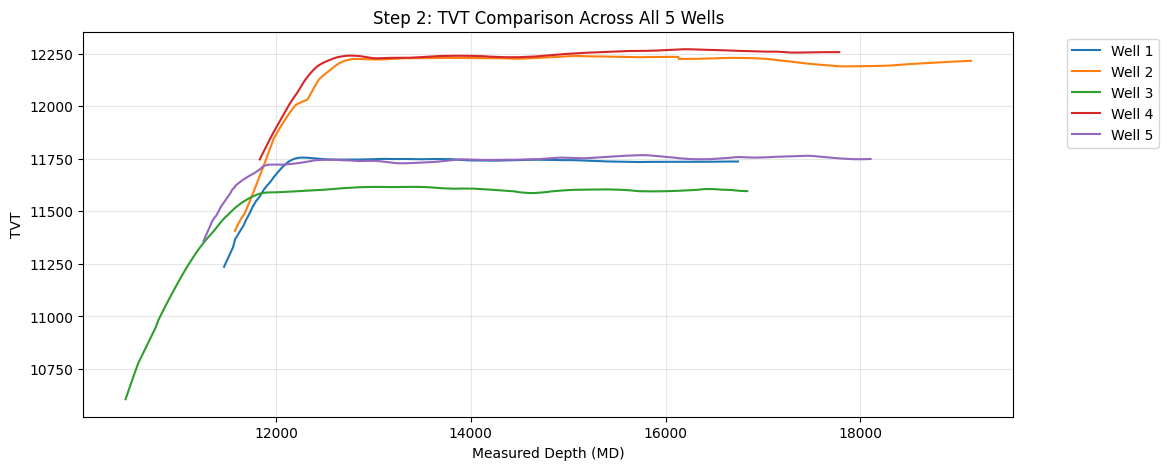

In [37]:
plt.figure(figsize=(12, 5))

# enumerate use karne se hume well ka index aur data dono mil jayenge
for i, well_df in enumerate(all_hor[0:5]):
    plt.plot(
        well_df["MD"],
        well_df["TVT"],
        label=f"Well {i+1}"  # Yeh har well ko 'Well 1' 'Well 2' ka label de dega
    )

plt.xlabel("Measured Depth (MD)")
plt.ylabel("TVT")
plt.title("Step 2: TVT Comparison Across All 5 Wells")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  
plt.grid(True, alpha=0.3)
plt.show()

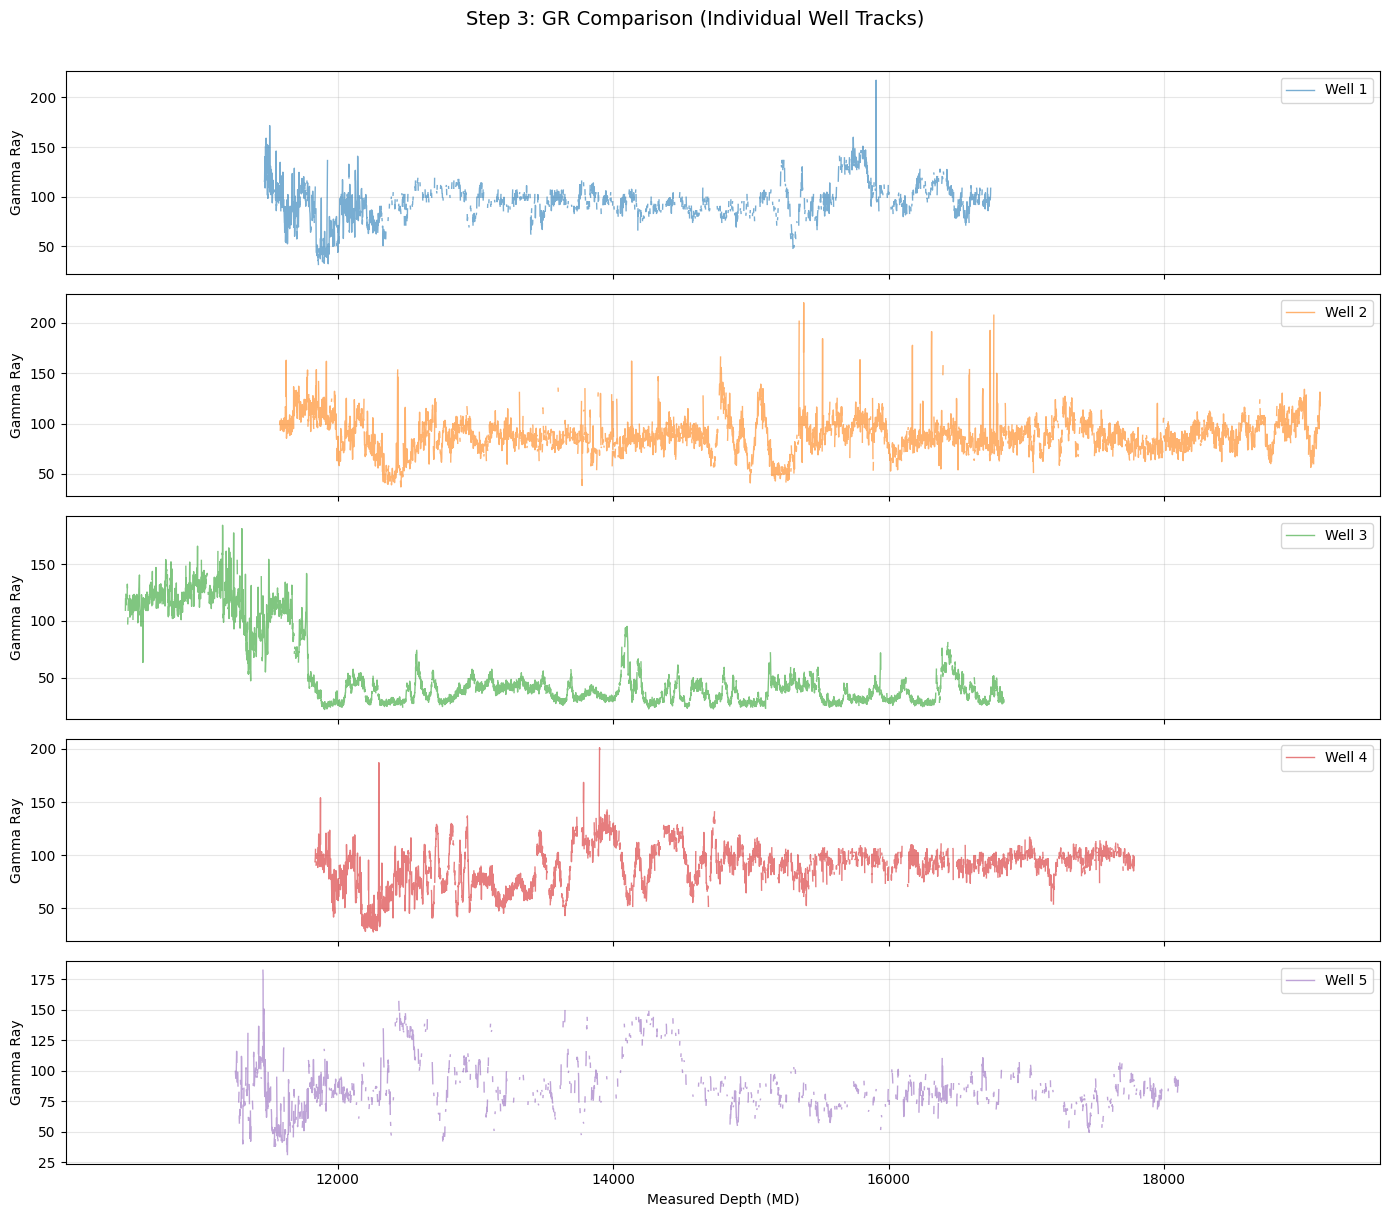

In [38]:

fig, axes = plt.subplots(5, 1, figsize=(14, 12), sharex=True)

for i, well_df in enumerate(all_hor[0:5]):
    ax = axes[i]
    
    ax.plot(
        well_df["MD"],
        well_df["GR"],
        color=f'C{i}',
        alpha=0.6,
        linewidth=1,
        label=f"Well {i+1}"
    )
    
    ax.set_ylabel("Gamma Ray")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

plt.xlabel("Measured Depth (MD)")
plt.suptitle("Step 3: GR Comparison (Individual Well Tracks)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
plt.show()

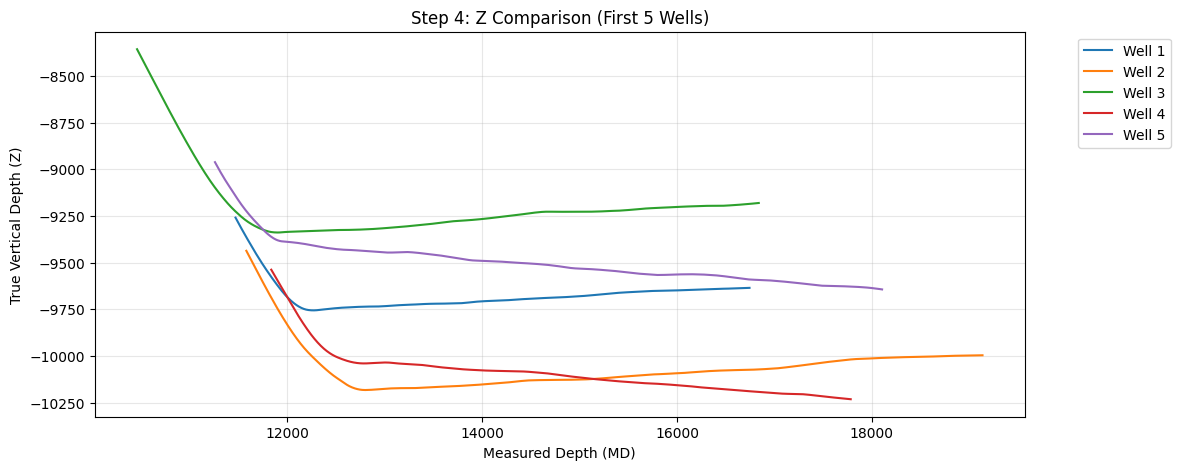

In [39]:
plt.figure(figsize=(12, 5))

for i, well_df in enumerate(all_hor[0:5]):
    plt.plot(
        well_df["MD"],
        well_df["Z"],
        label=f"Well {i+1}"  
    )

plt.xlabel("Measured Depth (MD)")
plt.ylabel("True Vertical Depth (Z)")
plt.title("Step 4: Z Comparison (First 5 Wells)")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  
plt.grid(True, alpha=0.3)
plt.show()

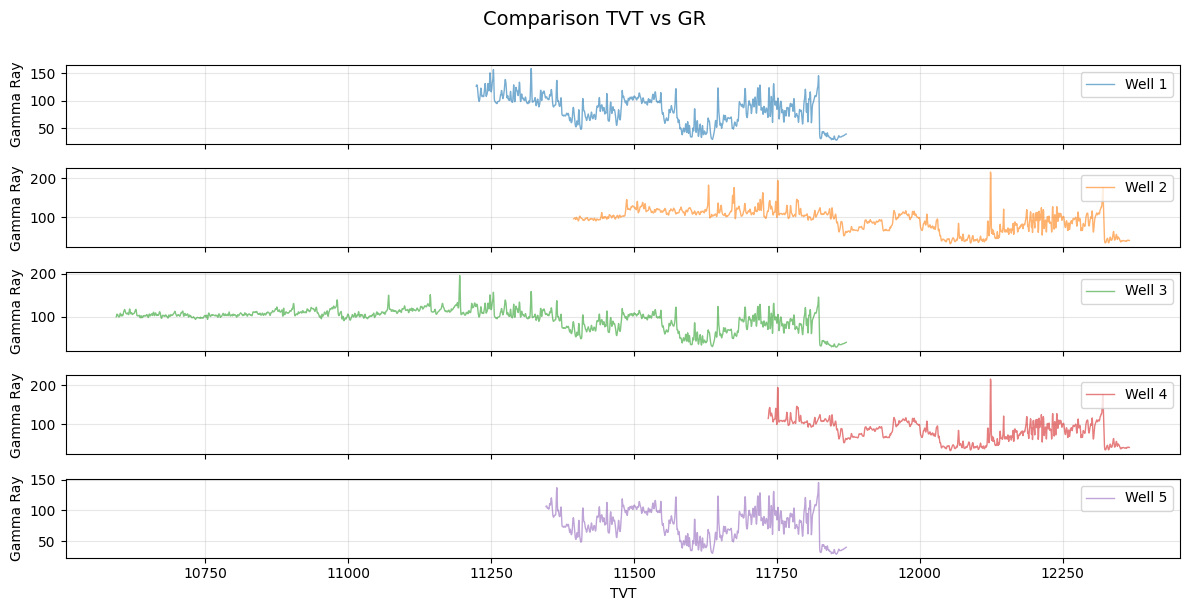

In [40]:

fig, axes = plt.subplots(5, 1, figsize=(12,6), sharex=True)

for i, well_df in enumerate(all_typ[0:5]):
    ax = axes[i]
    
    ax.plot(
        well_df["TVT"],
        well_df["GR"],
        color=f'C{i}',
        alpha=0.6,
        linewidth=1,
        label=f"Well {i+1}"
    )
    
    ax.set_ylabel("Gamma Ray")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

plt.xlabel("TVT")
plt.suptitle("Comparison TVT vs GR", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
plt.show()